### What this notebook does

Feature selection originally performed on the full dataset (n = 270) has been revised
to use **each seed's training data only (n ≈ 189)**, eliminating data leakage.

| Step | Original | Revised |
|---|---|---|
| ANOVA | All 270 samples, label-based grouping | Train only, **day-based grouping (consistent with original approach)** |
| Fold-change | All 270 samples, Δmean between classes | Train only, **max − min of day-wise CLR means (consistent with original approach)** |
| VIP (PLS-DA) | Fit on all 270 samples | Fit on training data only |
| Class labels | Defined in a separate notebook | Fixed seed-42 threshold from `labeling.ipynb` |

### Four Conditions

| Condition | Labeling | Feature Selection |
|---|---|---|
| 1 | Optuna (seed-42 threshold) | Fold-change Top 10 |
| 2 | Optuna (seed-42 threshold) | VIP ≥ 1.0 |
| 3 | K-means (seed-42 threshold) | Fold-change Top 10 |
| 4 | K-means (seed-42 threshold) | VIP ≥ 1.0 |

Visualizations use **seed-42 training data** as the representative set.

Pipeline order: `preprocessing.ipynb` → `labeling.ipynb` → **`screening.ipynb`** → `classification.ipynb`


## 1. import

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import f_oneway, chi2
from statsmodels.stats.multitest import multipletests
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
import re
import os

SEEDS      = [38, 39, 40, 41, 42, 43, 44, 45, 46, 47]
LABEL_SEED = 42
CODE_DIR   = "/home/admin-01/taeho/BRL_chicken/revision/code"
PKL_DIR    = f"{CODE_DIR}/data/pkl"

C_EARLY  = '#1f77b4'
C_INTER  = '#ff7f0e'
C_LATE   = '#9467bd'

SAVE_DIR = f"{CODE_DIR}/figures_screening"
os.makedirs(SAVE_DIR, exist_ok=True)

## 1. Data Load

`labeled_splits.pkl` — Optuna-based labels; thresholds derived from seed-42 training data and applied uniformly across all seeds  
`kmeans_labeled_splits.pkl` — K-means-based labels; same fixed-threshold approach  
Each split contains: train / test / val partitions with Label, Description, and TPC (log CFU/g)

In [2]:
with open(f"{PKL_DIR}/labeled_splits.pkl", "rb") as f:
    optuna_data = pickle.load(f)
with open(f"{PKL_DIR}/kmeans_labeled_splits.pkl", "rb") as f:
    kmeans_data = pickle.load(f)

feature_cols  = optuna_data['feature_cols']
optuna_splits = optuna_data['labeled_splits']
kmeans_splits = kmeans_data['labeled_splits']

def extract_day(desc):
    m = re.match(r'A(\d+)-\d+', str(desc))
    return int(m.group(1)) if m else np.nan

print(f"Features : {len(feature_cols)}")
print(f"Label: Early=0, Late=1, Intermediate=2 (seed-{LABEL_SEED} fixed threshold)")
for name, sp in [('Optuna', optuna_splits), ('K-means', kmeans_splits)]:
    tr = sp[LABEL_SEED]['train']
    print(f"  {name} seed-{LABEL_SEED} train: {tr['Label'].value_counts().sort_index().to_dict()}")

Features : 110
Label: Early=0, Late=1, Intermediate=2 (seed-42 fixed threshold)
  Optuna seed-42 train: {0: 99, 1: 28, 2: 62}
  K-means seed-42 train: {0: 74, 1: 61, 2: 54}


## 2. Helper Functions — Feature Selection

All functions operate on **training data only**, applied independently per seed.

- `anova_fdr`: One-way ANOVA with day-based grouping + Benjamini–Hochberg FDR correction (consistent with original approach, train only)
- `vip_select`: Features passing ANOVA → PLS-DA VIP ≥ 1.0 (train only)
- `fold_change_top10`: Max − min of day-wise CLR means (consistent with original approach, train only)

In [3]:
def anova_fdr(df_train, feature_cols, alpha=0.05):
    """Day-based one-way ANOVA + BH FDR (q < alpha). Train only."""
    df = df_train.copy()
    if 'Day' not in df.columns:
        df['Day'] = df['Description'].apply(extract_day)

    p_values, feats_valid = [], []
    for feat in feature_cols:
        groups = [g[feat].dropna().values for _, g in df.groupby('Day')]
        valid  = [g for g in groups if len(g) > 1]
        if len(valid) >= 2:
            _, p = f_oneway(*valid)
            p_values.append(p)
            feats_valid.append(feat)

    if not p_values:
        return [], pd.DataFrame(columns=['feature', 'p_value', 'q_value', 'significant'])

    p_arr = np.array(p_values)
    reject, q_arr, _, _ = multipletests(p_arr, method='fdr_bh', alpha=alpha)
    result_df = pd.DataFrame({
        'feature':     feats_valid,
        'p_value':     p_arr,
        'q_value':     q_arr,
        'significant': reject,
    }).sort_values('q_value').reset_index(drop=True)
    sig_feats = result_df.loc[result_df['significant'], 'feature'].tolist()
    return sig_feats, result_df


def vip_select(X_train, y_train, anova_features, threshold=1.0):
    """ANOVA pre-filter → PLS-DA VIP ≥ threshold. Train only."""
    X_in    = X_train[anova_features] if len(anova_features) >= 2 else X_train
    classes = sorted(np.unique(y_train))
    y_oh    = np.zeros((len(y_train), len(classes)))
    for i, c in enumerate(classes):
        y_oh[y_train == c, i] = 1.0
    n_comp = min(2, X_in.shape[1], len(classes) - 1)
    pls    = PLSRegression(n_components=n_comp, scale=False)
    pls.fit(X_in.values, y_oh)
    t, w, q_ = pls.x_scores_, pls.x_weights_, pls.y_loadings_
    ss        = np.sum(q_**2, axis=0) * np.sum(t**2, axis=0)
    vip_scores = np.sqrt(X_in.shape[1] * np.sum(w**2 * ss, axis=1) / np.sum(ss))
    vip_df = pd.DataFrame({
        'feature':   X_in.columns,
        'vip_score': vip_scores,
    }).sort_values('vip_score', ascending=False).reset_index(drop=True)
    selected = vip_df.loc[vip_df['vip_score'] >= threshold, 'feature'].tolist()
    return selected, vip_df, pls


def fold_change_top10(df_train, feature_cols, top_n=10):
    """Day별 CLR mean의 max − min (원본 방식). Train only."""
    df = df_train.copy()
    if 'Day' not in df.columns:
        df['Day'] = df['Description'].apply(extract_day)

    day_mean = df.groupby('Day')[feature_cols].mean()
    days     = sorted(day_mean.index)

    abs_change = day_mean.max() - day_mean.min()
    direction  = day_mean.loc[days[-1]] - day_mean.loc[days[0]]

    fc_df = pd.DataFrame({
        'feature':    feature_cols,
        'abs_change': abs_change.values,
        'direction':  direction.values,
    }).sort_values('abs_change', ascending=False).reset_index(drop=True)

    return fc_df['feature'].iloc[:top_n].tolist(), fc_df

## 3. Helper Functions — Figure

In [4]:
TPC_COL = 'TPC (log CFU/g)'


# ── Confidence Ellipse ───────────────────────────────────────────
def _draw_confidence_ellipse(ax, x, y, color, ci=0.95, alpha_fill=0.13, lw=1.5):
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    mean_x, mean_y = np.mean(x), np.mean(y)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle  = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    scale  = np.sqrt(chi2.ppf(ci, df=2))
    width  = 2 * scale * np.sqrt(max(eigenvalues[0], 0))
    height = 2 * scale * np.sqrt(max(eigenvalues[1], 0))
    ell = Ellipse(xy=(mean_x, mean_y), width=width, height=height, angle=angle,
                  facecolor=color, alpha=alpha_fill,
                  edgecolor=color, linewidth=lw, linestyle='--', zorder=1)
    ax.add_patch(ell)


# ── PCA Scatter ──────────────────────────────────────────────────
def pca_scatter(X_train, y_train, features, title, save_path):
    feats = [f for f in features if f in X_train.columns]
    if len(feats) < 2:
        print("[SKIP] features < 2"); return
    pca = PCA(n_components=2)
    T   = pca.fit_transform(X_train[feats].values)
    exp = pca.explained_variance_ratio_ * 100

    fig, ax = plt.subplots(figsize=(7, 6))
    for lbl, lname, col in [(0, 'Early', C_EARLY), (2, 'Intermediate', C_INTER), (1, 'Late', C_LATE)]:
        m = y_train == lbl
        _draw_confidence_ellipse(ax, T[m, 0], T[m, 1], col)
        ax.scatter(T[m, 0], T[m, 1], c=col, label=f'{lname} (n={m.sum()})',
                   alpha=0.80, s=55, edgecolors='white', linewidths=0.4, zorder=2)
    ax.axhline(0, color='gray', lw=0.4)
    ax.axvline(0, color='gray', lw=0.4)
    ax.set_xlabel(f'PC1 ({exp[0]:.1f}%)', fontsize=11)
    ax.set_ylabel(f'PC2 ({exp[1]:.1f}%)', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


# ── PLS-DA Scatter ───────────────────────────────────────────────
def plsda_scatter(X_train, y_train, features, title, save_path):
    feats = [f for f in features if f in X_train.columns]
    if len(feats) < 2:
        print("[SKIP] features < 2"); return
    classes = sorted(np.unique(y_train))
    y_oh    = np.zeros((len(y_train), len(classes)))
    for i, c in enumerate(classes):
        y_oh[y_train == c, i] = 1.0
    n_comp = min(2, len(feats), len(classes) - 1)
    pls    = PLSRegression(n_components=n_comp, scale=False)
    pls.fit(X_train[feats].values, y_oh)
    T   = pls.transform(X_train[feats].values)
    exp = np.var(T, axis=0) / np.var(T).sum() * 100

    fig, ax = plt.subplots(figsize=(7, 6))
    for lbl, lname, col in [(0, 'Early', C_EARLY), (2, 'Intermediate', C_INTER), (1, 'Late', C_LATE)]:
        m = y_train == lbl
        _draw_confidence_ellipse(ax, T[m, 0], T[m, 1], col)
        ax.scatter(T[m, 0], T[m, 1], c=col, label=f'{lname} (n={m.sum()})',
                   alpha=0.80, s=55, edgecolors='white', linewidths=0.4, zorder=2)
    ax.axhline(0, color='gray', lw=0.4)
    ax.axvline(0, color='gray', lw=0.4)
    ax.set_xlabel(f'PLS-DA 1 ({exp[0]:.1f}%)', fontsize=11)
    ax.set_ylabel(f'PLS-DA 2 ({exp[1]:.1f}%)', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


# ── 4-panel용 내부 scatter ──────────────────────────────────────
def _scatter_on_ax(ax, T, y_train, exp, xlabel, ylabel):
    for lbl, lname, col in [(0, 'Early', C_EARLY), (2, 'Intermediate', C_INTER), (1, 'Late', C_LATE)]:
        m = y_train == lbl
        _draw_confidence_ellipse(ax, T[m, 0], T[m, 1], col)
        ax.scatter(T[m, 0], T[m, 1], c=col, label=f'{lname} (n={m.sum()})',
                   alpha=0.80, s=40, edgecolors='white', linewidths=0.3, zorder=2)
    ax.axhline(0, color='gray', lw=0.4)
    ax.axvline(0, color='gray', lw=0.4)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=8, framealpha=0.6)
    ax.spines[['top', 'right']].set_visible(False)


# ── 4-panel PCA ─────────────────────────────────────────────────
def pca_4panel(datasets, save_path):
    """datasets: list of 4 dicts {'X', 'y', 'feats', 'label'}"""
    fig, axes = plt.subplots(2, 2, figsize=(13, 11))
    for ax, d in zip(axes.flat, datasets):
        feats = [f for f in d['feats'] if f in d['X'].columns]
        pca   = PCA(n_components=2)
        T     = pca.fit_transform(d['X'][feats].values)
        exp   = pca.explained_variance_ratio_ * 100
        _scatter_on_ax(ax, T, d['y'], exp,
                       f'PC1 ({exp[0]:.1f}%)', f'PC2 ({exp[1]:.1f}%)')
        ax.set_title(d['label'], fontsize=10, pad=4)
    fig.suptitle('PCA — 95% confidence ellipse (seed-42 train)', fontsize=12, y=1.01)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


# ── 4-panel PLS-DA ───────────────────────────────────────────────
def plsda_4panel(datasets, save_path):
    fig, axes = plt.subplots(2, 2, figsize=(13, 11))
    for ax, d in zip(axes.flat, datasets):
        feats   = [f for f in d['feats'] if f in d['X'].columns]
        classes = sorted(np.unique(d['y']))
        y_oh    = np.zeros((len(d['y']), len(classes)))
        for i, c in enumerate(classes):
            y_oh[d['y'] == c, i] = 1.0
        n_comp  = min(2, len(feats), len(classes) - 1)
        pls     = PLSRegression(n_components=n_comp, scale=False)
        pls.fit(d['X'][feats].values, y_oh)
        T       = pls.transform(d['X'][feats].values)
        exp     = np.var(T, axis=0) / np.var(T).sum() * 100
        _scatter_on_ax(ax, T, d['y'], exp,
                       f'PLS-DA 1 ({exp[0]:.1f}%)', f'PLS-DA 2 ({exp[1]:.1f}%)')
        ax.set_title(d['label'], fontsize=10, pad=4)
    fig.suptitle('PLS-DA — 95% confidence ellipse (seed-42 train)', fontsize=12, y=1.01)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


# ── PC1 Loading Bar ──────────────────────────────────────────────
def pc1_loading_bar(X_train, features, title, save_path, top_n=10):
    feats = [f for f in features if f in X_train.columns]
    if len(feats) < 2:
        print("[SKIP] features < 2"); return
    pca      = PCA(n_components=2)
    pca.fit(X_train[feats].values)
    loadings = pca.components_[0]
    short    = [f.replace('g__', '') for f in feats]

    order        = np.argsort(np.abs(loadings))[::-1][:top_n]
    loadings_top = loadings[order]
    short_top    = [short[i] for i in order]
    colors       = [C_LATE if v >= 0 else C_EARLY for v in loadings_top]

    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.barh(range(len(order)), loadings_top, color=colors, alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(short_top, fontsize=9)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('PC1 Loading', fontsize=11)
    if title:
        ax.set_title(title, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


# ── PLS1 Loading Bar ─────────────────────────────────────────────
def pls1_loading_bar(X_train, y_train, features, save_path, top_n=10):
    feats = [f for f in features if f in X_train.columns]
    if len(feats) < 2:
        print("[SKIP] features < 2"); return
    classes = sorted(np.unique(y_train))
    y_oh    = np.zeros((len(y_train), len(classes)))
    for i, c in enumerate(classes):
        y_oh[y_train == c, i] = 1.0
    n_comp = min(2, len(feats), len(classes) - 1)
    pls    = PLSRegression(n_components=n_comp, scale=False)
    pls.fit(X_train[feats].values, y_oh)
    loadings = pls.x_loadings_[:, 0]
    short    = [f.replace('g__', '') for f in feats]

    order        = np.argsort(np.abs(loadings))[::-1][:top_n]
    loadings_top = loadings[order]
    short_top    = [short[i] for i in order]
    colors       = ['#2ca02c' if v >= 0 else '#bcbd22' for v in loadings_top]

    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.barh(range(len(order)), loadings_top, color=colors, alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(short_top, fontsize=9)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('PLS1 Loading', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


# ── Day-wise Trend ───────────────────────────────────────────────
def day_trend(df_train, features, title, save_path, max_feats=12):
    feats  = [f for f in features[:max_feats] if f in df_train.columns]
    df_day = df_train[feats + ['Day']].groupby('Day').mean()
    days   = sorted(df_day.index)

    fig, ax = plt.subplots(figsize=(10, 5))
    cmap    = plt.cm.tab20
    for i, feat in enumerate(feats):
        ax.plot(days, df_day.loc[days, feat],
                marker='o', markersize=4, linewidth=1.5,
                color=cmap(i / max(len(feats) - 1, 1)),
                label=feat.replace('g__', ''))
    ax.axvline(9, color='gray', linestyle=':', linewidth=1.0)
    ax.set_xlabel('Storage Day', fontsize=11)
    ax.set_ylabel('Mean CLR Abundance', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(days)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


# ── Correlation Heatmap ──────────────────────────────────────────
def corr_heatmap(df_train, features, title, save_path):
    feats = [f for f in features if f in df_train.columns]
    if len(feats) < 2:
        print("[SKIP] features < 2"); return

    cols   = feats + ([TPC_COL] if TPC_COL in df_train.columns else [])
    df_sub = df_train[cols].copy()
    df_sub.columns = [c.replace('g__', '') for c in cols]
    corr_df = df_sub.corr(method='spearman')

    mask  = np.triu(np.ones_like(corr_df, dtype=bool))
    fsize = max(6, 0.55 * len(cols))
    fig, ax = plt.subplots(figsize=(fsize, fsize * 0.9))
    sns.heatmap(corr_df, mask=mask, annot=False, cmap='RdBu_r',
                vmin=-1, vmax=1, ax=ax,
                square=True, linewidths=0.3,
                cbar_kws={'shrink': 0.8})
    if title:
        ax.set_title(title, fontsize=11, pad=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


print("All figure functions defined.")

All figure functions defined.


## 4. Feature Selection — Per Seed, All Conditions (seed = 42)

In [5]:
per_seed = {c: {} for c in ['cond1', 'cond2', 'cond3', 'cond4']}
store = {
    'cond1': {'fc_df': {}},
    'cond2': {'vip_df': {}, 'anova': {}},
    'cond3': {'fc_df': {}},
    'cond4': {'vip_df': {}, 'anova': {}},
}

for seed in SEEDS:
    # ── Optuna ─────────────────────────────────────────────────────
    opt_tr   = optuna_splits[seed]['train']
    X_o, y_o = opt_tr[feature_cols], opt_tr['Label'].values

    c1, fc1 = fold_change_top10(opt_tr, feature_cols)
    per_seed['cond1'][seed]        = c1
    store['cond1']['fc_df'][seed]  = fc1

    an2, _      = anova_fdr(opt_tr, feature_cols)
    c2, vip2, _ = vip_select(X_o, y_o, an2)
    per_seed['cond2'][seed]        = c2
    store['cond2']['vip_df'][seed] = vip2
    store['cond2']['anova'][seed]  = an2

    # ── K-means ────────────────────────────────────────────────────
    km_tr    = kmeans_splits[seed]['train']
    X_k, y_k = km_tr[feature_cols], km_tr['Label'].values

    c3, fc3 = fold_change_top10(km_tr, feature_cols)
    per_seed['cond3'][seed]        = c3
    store['cond3']['fc_df'][seed]  = fc3

    an4, _      = anova_fdr(km_tr, feature_cols)
    c4, vip4, _ = vip_select(X_k, y_k, an4)
    per_seed['cond4'][seed]        = c4
    store['cond4']['vip_df'][seed] = vip4
    store['cond4']['anova'][seed]  = an4

    print(f"seed={seed} | C1={len(c1):2d} | "
          f"C2={len(c2):2d}(ANOVA={len(an2):3d}) | "
          f"C3={len(c3):2d} | "
          f"C4={len(c4):2d}(ANOVA={len(an4):3d})")

# ── seed-42 기준 시각화 변수 ──────────────────────────────────────
opt42 = optuna_splits[LABEL_SEED]['train'].copy()
km42  = kmeans_splits[LABEL_SEED]['train'].copy()
X42_opt, y42_opt = opt42[feature_cols], opt42['Label'].values
X42_km,  y42_km  = km42[feature_cols],  km42['Label'].values

if 'Day' not in opt42.columns:
    opt42['Day'] = opt42['Description'].apply(extract_day)
if 'Day' not in km42.columns:
    km42['Day'] = km42['Description'].apply(extract_day)

c1_feats = per_seed['cond1'][LABEL_SEED]
c2_feats = per_seed['cond2'][LABEL_SEED]
c3_feats = per_seed['cond3'][LABEL_SEED]
c4_feats = per_seed['cond4'][LABEL_SEED]

print(f"\nSeed-{LABEL_SEED} | C1={len(c1_feats)}, C2={len(c2_feats)}, "
      f"C3={len(c3_feats)}, C4={len(c4_feats)}")

seed=38 | C1=10 | C2=22(ANOVA=102) | C3=10 | C4=28(ANOVA=102)
seed=39 | C1=10 | C2=25(ANOVA=107) | C3=10 | C4=31(ANOVA=107)
seed=40 | C1=10 | C2=28(ANOVA=101) | C3=10 | C4=29(ANOVA=101)
seed=41 | C1=10 | C2=25(ANOVA=101) | C3=10 | C4=28(ANOVA=101)
seed=42 | C1=10 | C2=23(ANOVA=100) | C3=10 | C4=30(ANOVA=100)
seed=43 | C1=10 | C2=26(ANOVA=104) | C3=10 | C4=28(ANOVA=104)
seed=44 | C1=10 | C2=28(ANOVA=104) | C3=10 | C4=28(ANOVA=104)
seed=45 | C1=10 | C2=23(ANOVA=103) | C3=10 | C4=27(ANOVA=103)
seed=46 | C1=10 | C2=24(ANOVA= 99) | C3=10 | C4=28(ANOVA= 99)
seed=47 | C1=10 | C2=24(ANOVA= 97) | C3=10 | C4=28(ANOVA= 97)

Seed-42 | C1=10, C2=23, C3=10, C4=30


## 5. Fold-change Bar Chart — Cond 1 & 3

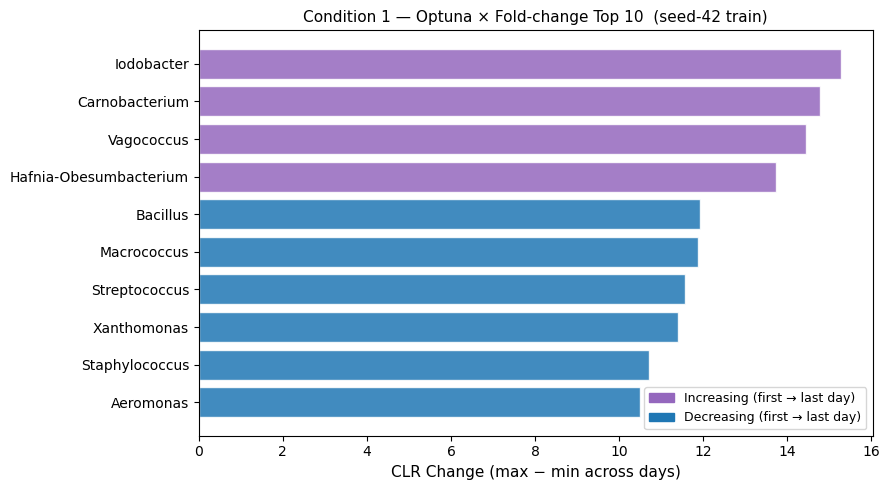

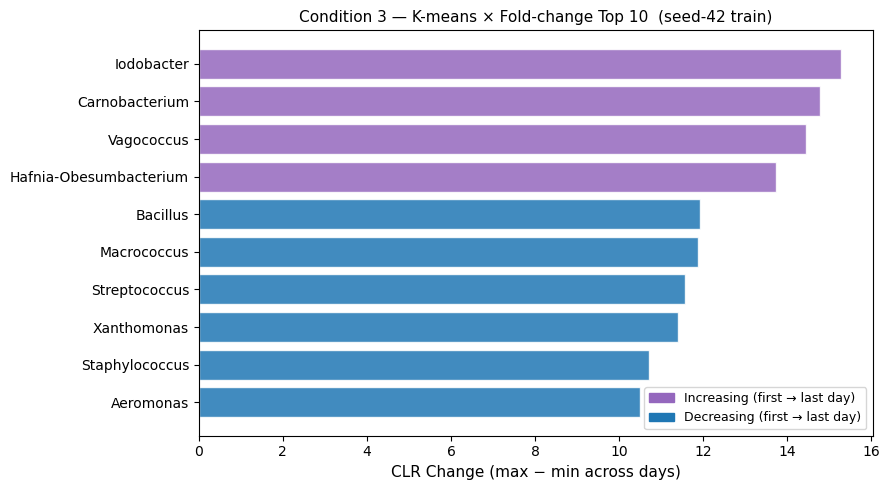

In [6]:
# ── Condition 1: Optuna × FC Top10 ──────────────────────────────
fc_c1 = store['cond1']['fc_df'][LABEL_SEED].copy()
fc_c1['short'] = fc_c1['feature'].str.replace('g__', '', regex=False)

fig, ax = plt.subplots(figsize=(9, 5))
vals   = fc_c1['abs_change'].iloc[:10]
dirs   = fc_c1['direction'].iloc[:10]
colors = [C_LATE if d >= 0 else C_EARLY for d in dirs]
ax.barh(range(10), vals, color=colors, alpha=0.85, edgecolor='white')
ax.set_yticks(range(10))
ax.set_yticklabels(fc_c1['short'].iloc[:10], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('CLR Change (max − min across days)', fontsize=11)
ax.set_title(f'Condition 1 — Optuna × Fold-change Top 10  (seed-{LABEL_SEED} train)', fontsize=11)
ax.legend(handles=[
    mpatches.Patch(color=C_LATE,  label='Increasing (first → last day)'),
    mpatches.Patch(color=C_EARLY, label='Decreasing (first → last day)'),
], fontsize=9)
fig.tight_layout()
fig.savefig(f"{SAVE_DIR}/fig_screen_cond1_fc.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Condition 3: K-means × FC Top10 ─────────────────────────────
fc_c3 = store['cond3']['fc_df'][LABEL_SEED].copy()
fc_c3['short'] = fc_c3['feature'].str.replace('g__', '', regex=False)

fig, ax = plt.subplots(figsize=(9, 5))
vals   = fc_c3['abs_change'].iloc[:10]
dirs   = fc_c3['direction'].iloc[:10]
colors = [C_LATE if d >= 0 else C_EARLY for d in dirs]
ax.barh(range(10), vals, color=colors, alpha=0.85, edgecolor='white')
ax.set_yticks(range(10))
ax.set_yticklabels(fc_c3['short'].iloc[:10], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('CLR Change (max − min across days)', fontsize=11)
ax.set_title(f'Condition 3 — K-means × Fold-change Top 10  (seed-{LABEL_SEED} train)', fontsize=11)
ax.legend(handles=[
    mpatches.Patch(color=C_LATE,  label='Increasing (first → last day)'),
    mpatches.Patch(color=C_EARLY, label='Decreasing (first → last day)'),
], fontsize=9)
fig.tight_layout()
fig.savefig(f"{SAVE_DIR}/fig_screen_cond3_fc.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. VIP Score Ranking — Cond 2 & 4

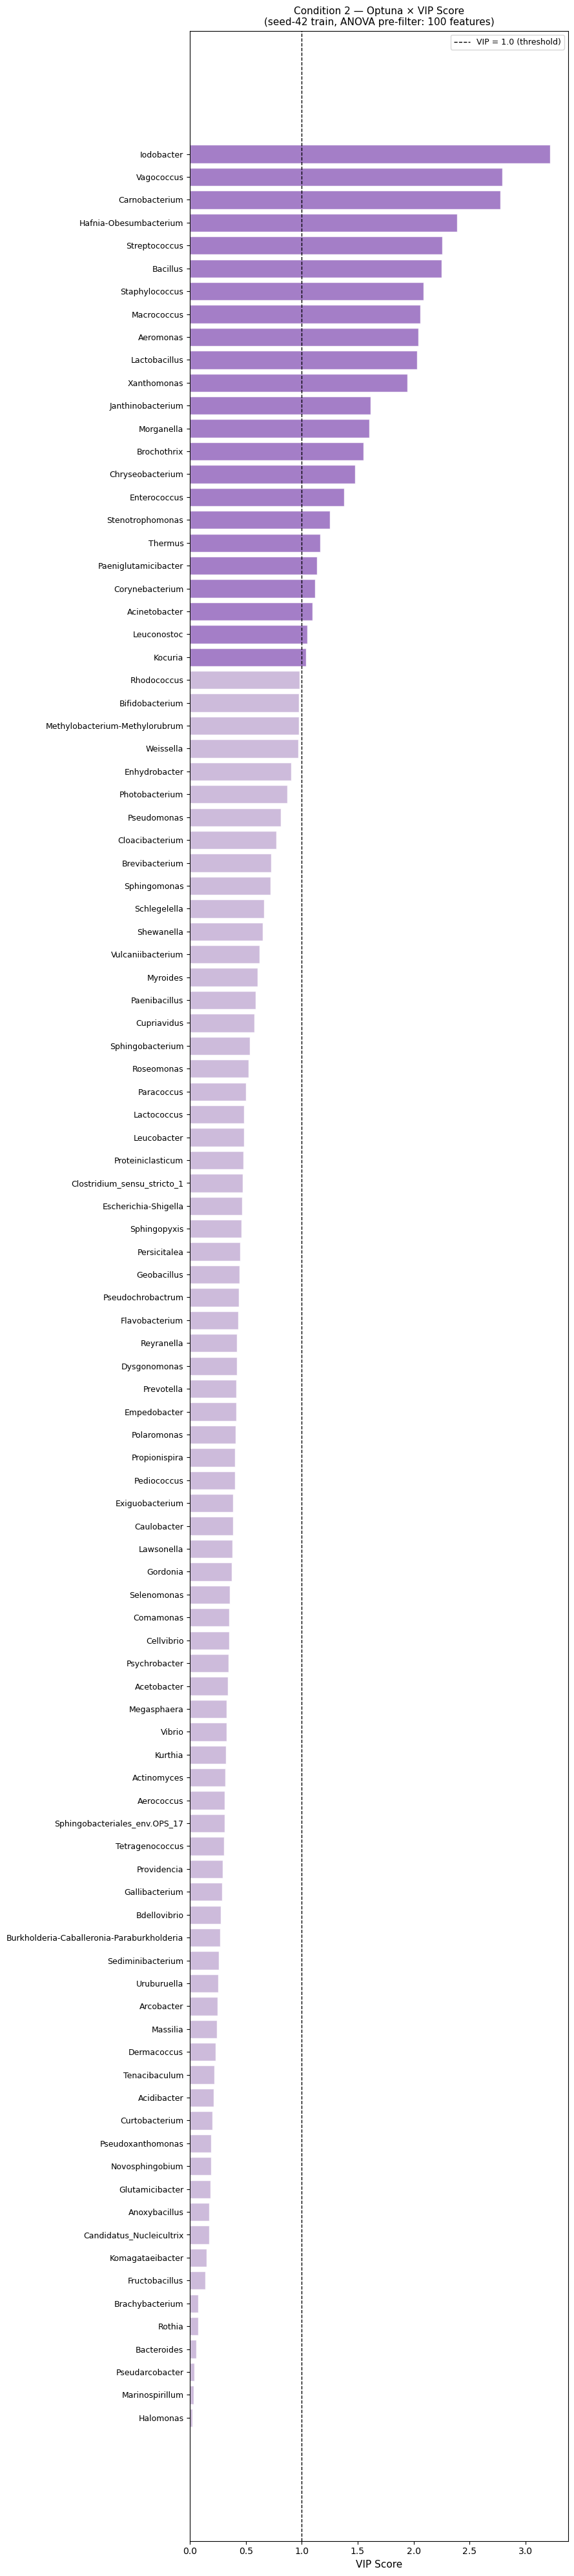

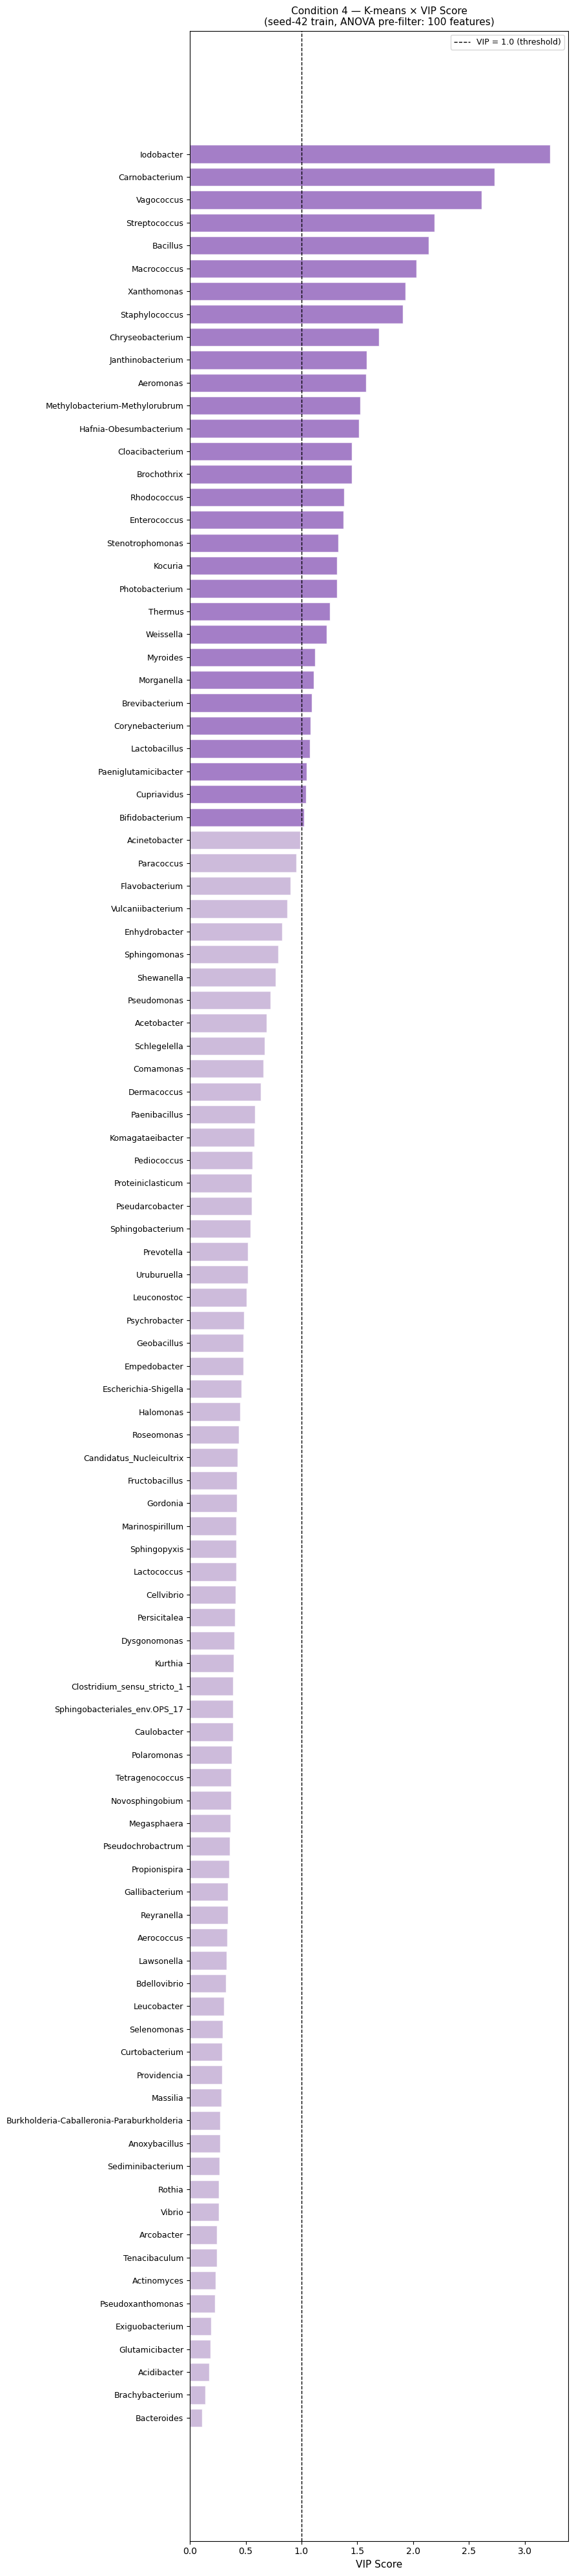

In [7]:
# ── Condition 2: Optuna × VIP ────────────────────────────────────
vip_c2 = store['cond2']['vip_df'][LABEL_SEED].copy()
vip_c2['short'] = vip_c2['feature'].str.replace('g__', '', regex=False)
n = len(vip_c2)

fig, ax = plt.subplots(figsize=(9, max(4, 0.40 * n)))
colors  = [C_LATE if s >= 1.0 else '#c5b0d5' for s in vip_c2['vip_score']]
ax.barh(range(n), vip_c2['vip_score'], color=colors, alpha=0.85, edgecolor='white')
ax.set_yticks(range(n))
ax.set_yticklabels(vip_c2['short'], fontsize=9)
ax.invert_yaxis()
ax.axvline(1.0, color='black', linestyle='--', linewidth=1.0, label='VIP = 1.0 (threshold)')
ax.set_xlabel('VIP Score', fontsize=11)
ax.set_title(
    f'Condition 2 — Optuna × VIP Score\n'
    f'(seed-{LABEL_SEED} train, ANOVA pre-filter: {len(store["cond2"]["anova"][LABEL_SEED])} features)',
    fontsize=11)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f"{SAVE_DIR}/fig_screen_cond2_vip.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Condition 4: K-means × VIP ──────────────────────────────────
vip_c4 = store['cond4']['vip_df'][LABEL_SEED].copy()
vip_c4['short'] = vip_c4['feature'].str.replace('g__', '', regex=False)
n = len(vip_c4)

fig, ax = plt.subplots(figsize=(9, max(4, 0.40 * n)))
colors  = [C_LATE if s >= 1.0 else '#c5b0d5' for s in vip_c4['vip_score']]
ax.barh(range(n), vip_c4['vip_score'], color=colors, alpha=0.85, edgecolor='white')
ax.set_yticks(range(n))
ax.set_yticklabels(vip_c4['short'], fontsize=9)
ax.invert_yaxis()
ax.axvline(1.0, color='black', linestyle='--', linewidth=1.0, label='VIP = 1.0 (threshold)')
ax.set_xlabel('VIP Score', fontsize=11)
ax.set_title(
    f'Condition 4 — K-means × VIP Score\n'
    f'(seed-{LABEL_SEED} train, ANOVA pre-filter: {len(store["cond4"]["anova"][LABEL_SEED])} features)',
    fontsize=11)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f"{SAVE_DIR}/fig_screen_cond4_vip.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. PCA Scatter — Cond 1, 2, 3, 4

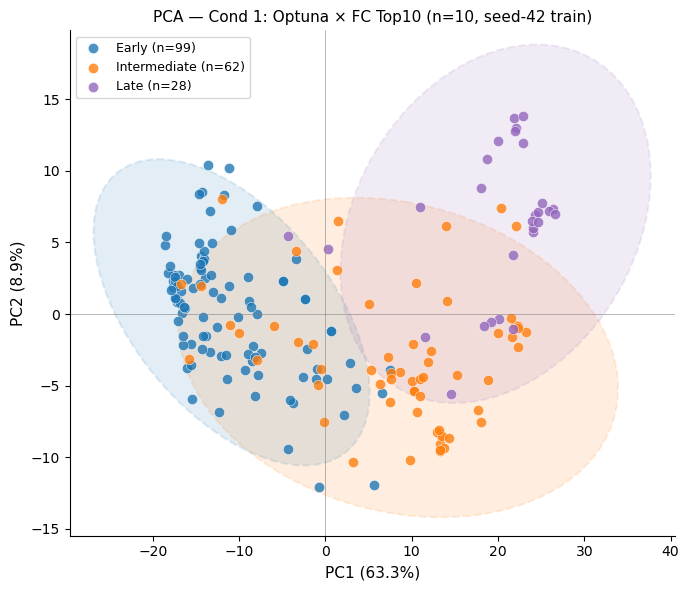

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_screen_cond1_pca.png


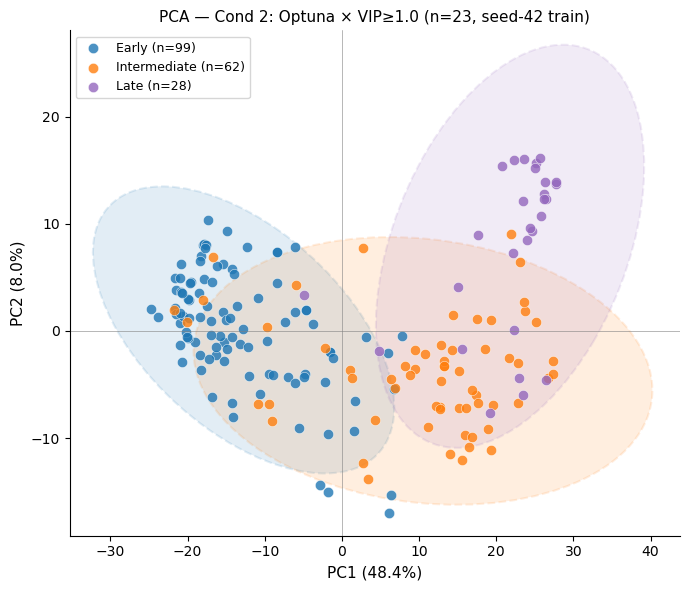

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_screen_cond2_pca.png


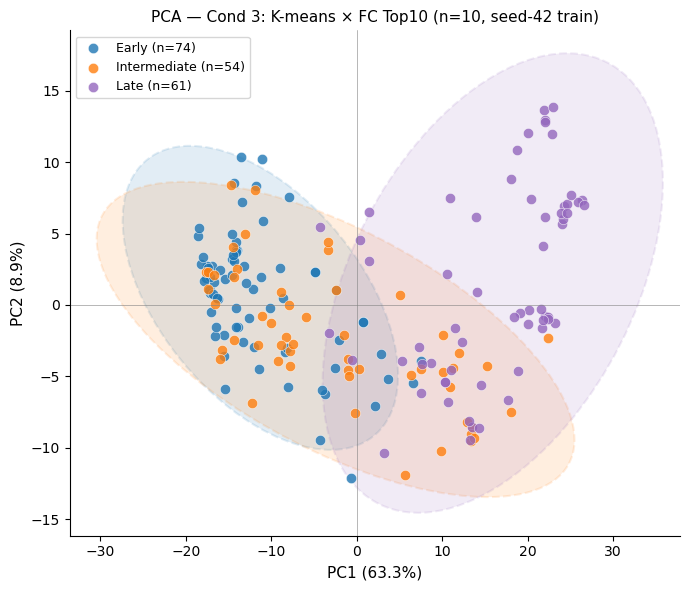

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_screen_cond3_pca.png


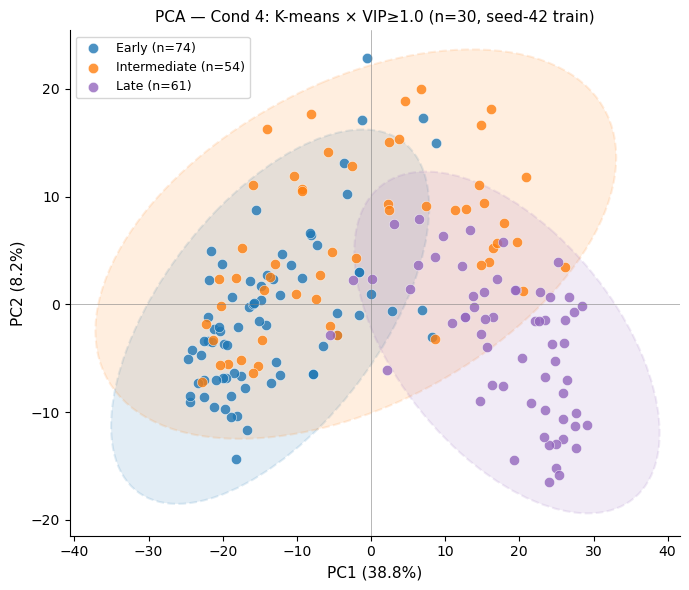

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_screen_cond4_pca.png


In [8]:
pca_scatter(X42_opt, y42_opt, c1_feats,
            f'PCA — Cond 1: Optuna × FC Top10 (n={len(c1_feats)}, seed-{LABEL_SEED} train)',
            f"{SAVE_DIR}/fig_screen_cond1_pca.png")

pca_scatter(X42_opt, y42_opt, c2_feats,
            f'PCA — Cond 2: Optuna × VIP≥1.0 (n={len(c2_feats)}, seed-{LABEL_SEED} train)',
            f"{SAVE_DIR}/fig_screen_cond2_pca.png")

pca_scatter(X42_km, y42_km, c3_feats,
            f'PCA — Cond 3: K-means × FC Top10 (n={len(c3_feats)}, seed-{LABEL_SEED} train)',
            f"{SAVE_DIR}/fig_screen_cond3_pca.png")

pca_scatter(X42_km, y42_km, c4_feats,
            f'PCA — Cond 4: K-means × VIP≥1.0 (n={len(c4_feats)}, seed-{LABEL_SEED} train)',
            f"{SAVE_DIR}/fig_screen_cond4_pca.png")

## 8. PLS-DA Scatter — Cond 1, 2, 3, 4

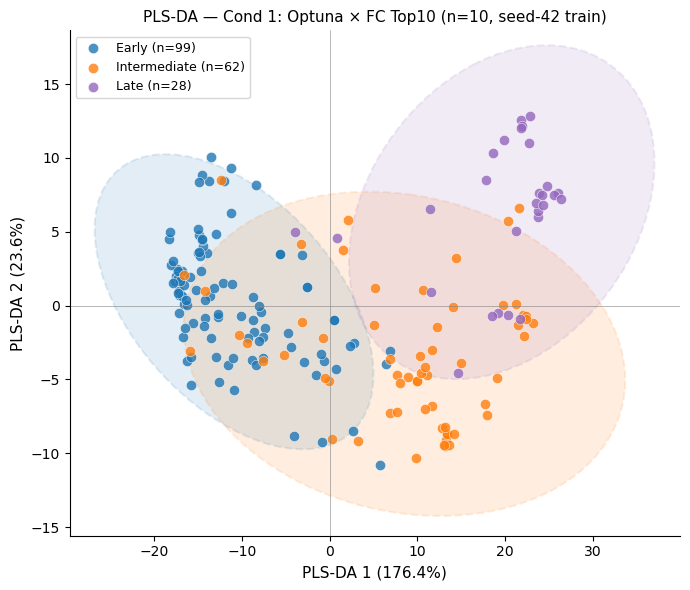

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_screen_cond1_plsda.png


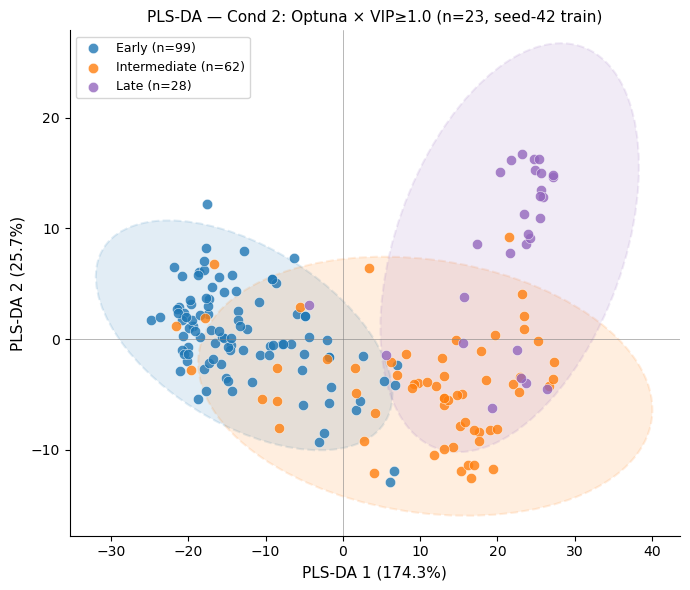

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_screen_cond2_plsda.png


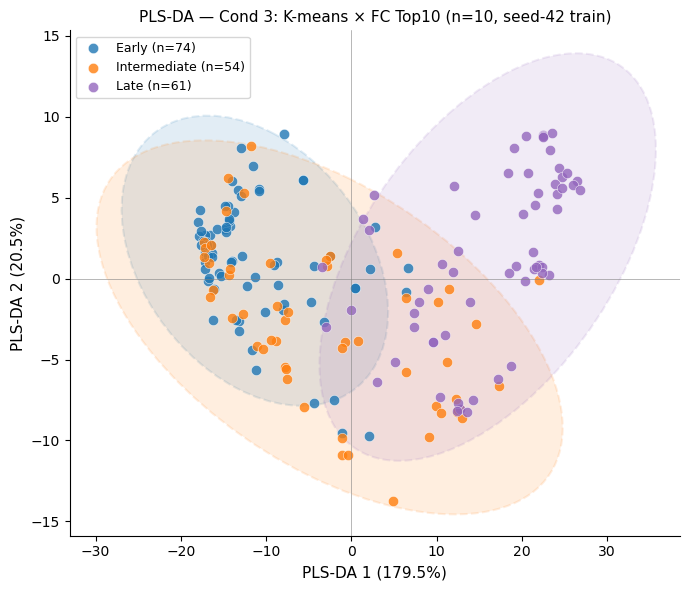

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_screen_cond3_plsda.png


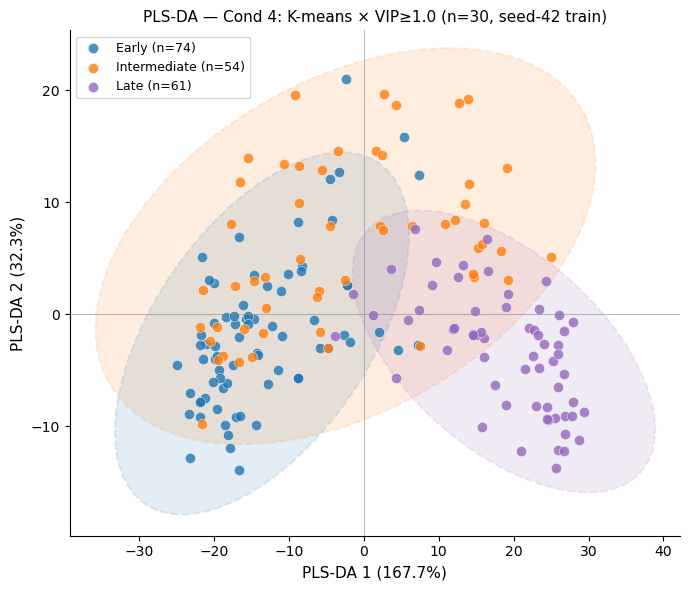

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_screen_cond4_plsda.png


In [9]:
plsda_scatter(X42_opt, y42_opt, c1_feats,
              f'PLS-DA — Cond 1: Optuna × FC Top10 (n={len(c1_feats)}, seed-{LABEL_SEED} train)',
              f"{SAVE_DIR}/fig_screen_cond1_plsda.png")

plsda_scatter(X42_opt, y42_opt, c2_feats,
              f'PLS-DA — Cond 2: Optuna × VIP≥1.0 (n={len(c2_feats)}, seed-{LABEL_SEED} train)',
              f"{SAVE_DIR}/fig_screen_cond2_plsda.png")

plsda_scatter(X42_km, y42_km, c3_feats,
              f'PLS-DA — Cond 3: K-means × FC Top10 (n={len(c3_feats)}, seed-{LABEL_SEED} train)',
              f"{SAVE_DIR}/fig_screen_cond3_plsda.png")

plsda_scatter(X42_km, y42_km, c4_feats,
              f'PLS-DA — Cond 4: K-means × VIP≥1.0 (n={len(c4_feats)}, seed-{LABEL_SEED} train)',
              f"{SAVE_DIR}/fig_screen_cond4_plsda.png")

## 9. Day-wise Trend — Cond 1, 2, 3, 4

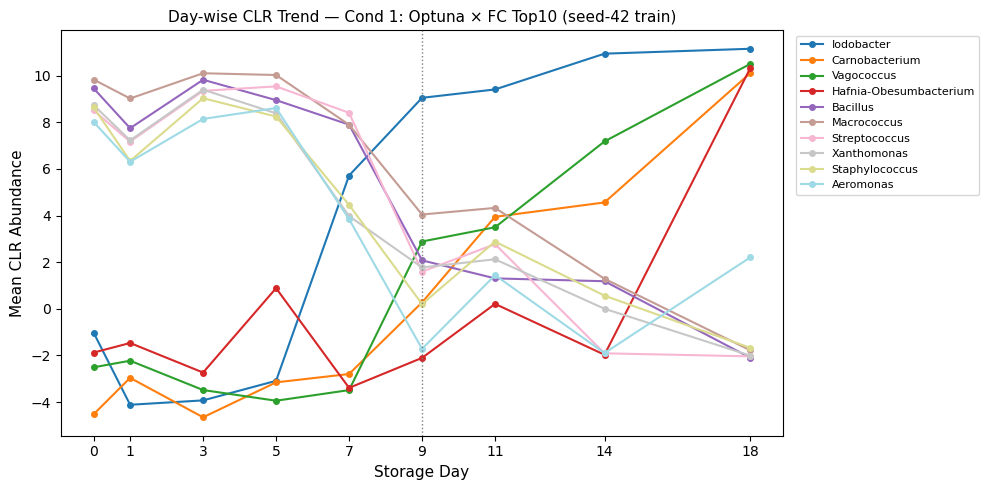

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_screen_cond1_daytrend.png


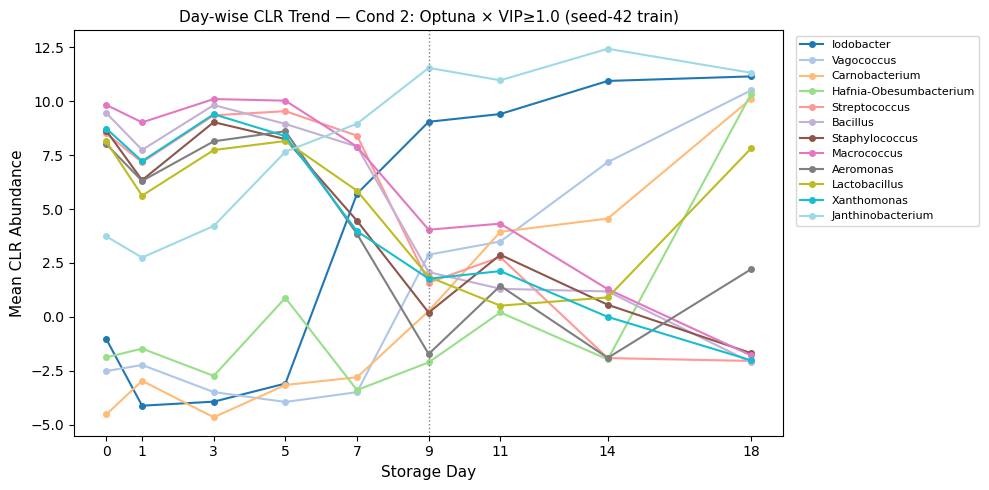

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_screen_cond2_daytrend.png


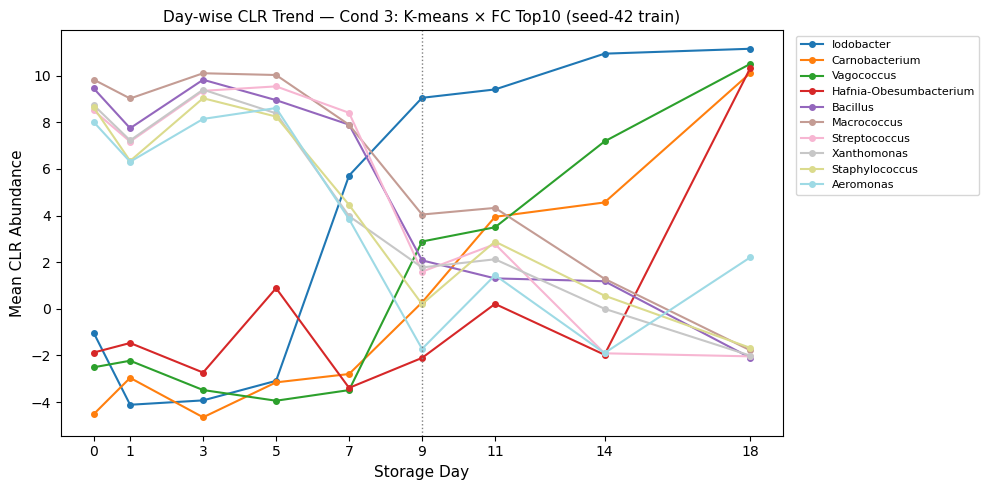

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_screen_cond3_daytrend.png


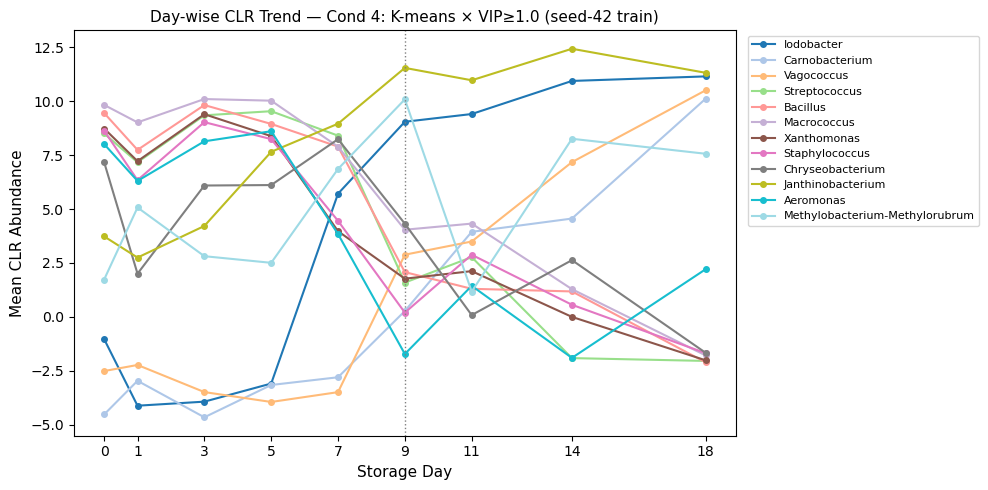

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_screen_cond4_daytrend.png


In [10]:
day_trend(opt42, c1_feats,
          f'Day-wise CLR Trend — Cond 1: Optuna × FC Top10 (seed-{LABEL_SEED} train)',
          f"{SAVE_DIR}/fig_screen_cond1_daytrend.png")

day_trend(opt42, c2_feats,
          f'Day-wise CLR Trend — Cond 2: Optuna × VIP≥1.0 (seed-{LABEL_SEED} train)',
          f"{SAVE_DIR}/fig_screen_cond2_daytrend.png")

day_trend(km42, c3_feats,
          f'Day-wise CLR Trend — Cond 3: K-means × FC Top10 (seed-{LABEL_SEED} train)',
          f"{SAVE_DIR}/fig_screen_cond3_daytrend.png")

day_trend(km42, c4_feats,
          f'Day-wise CLR Trend — Cond 4: K-means × VIP≥1.0 (seed-{LABEL_SEED} train)',
          f"{SAVE_DIR}/fig_screen_cond4_daytrend.png")

## 10. Correlation Heatmap (Spearman)

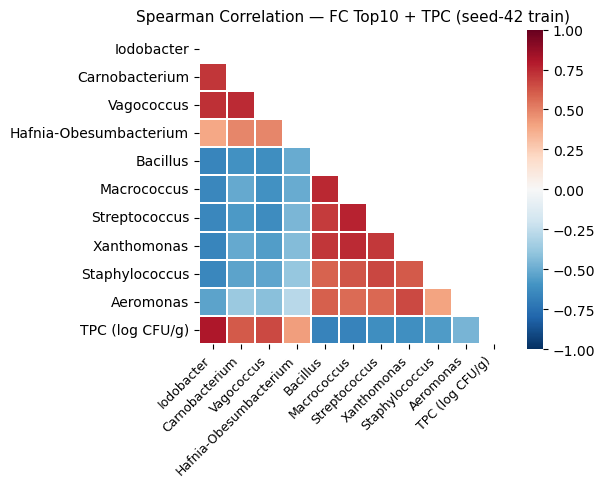

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_screen_fc10_corr.png


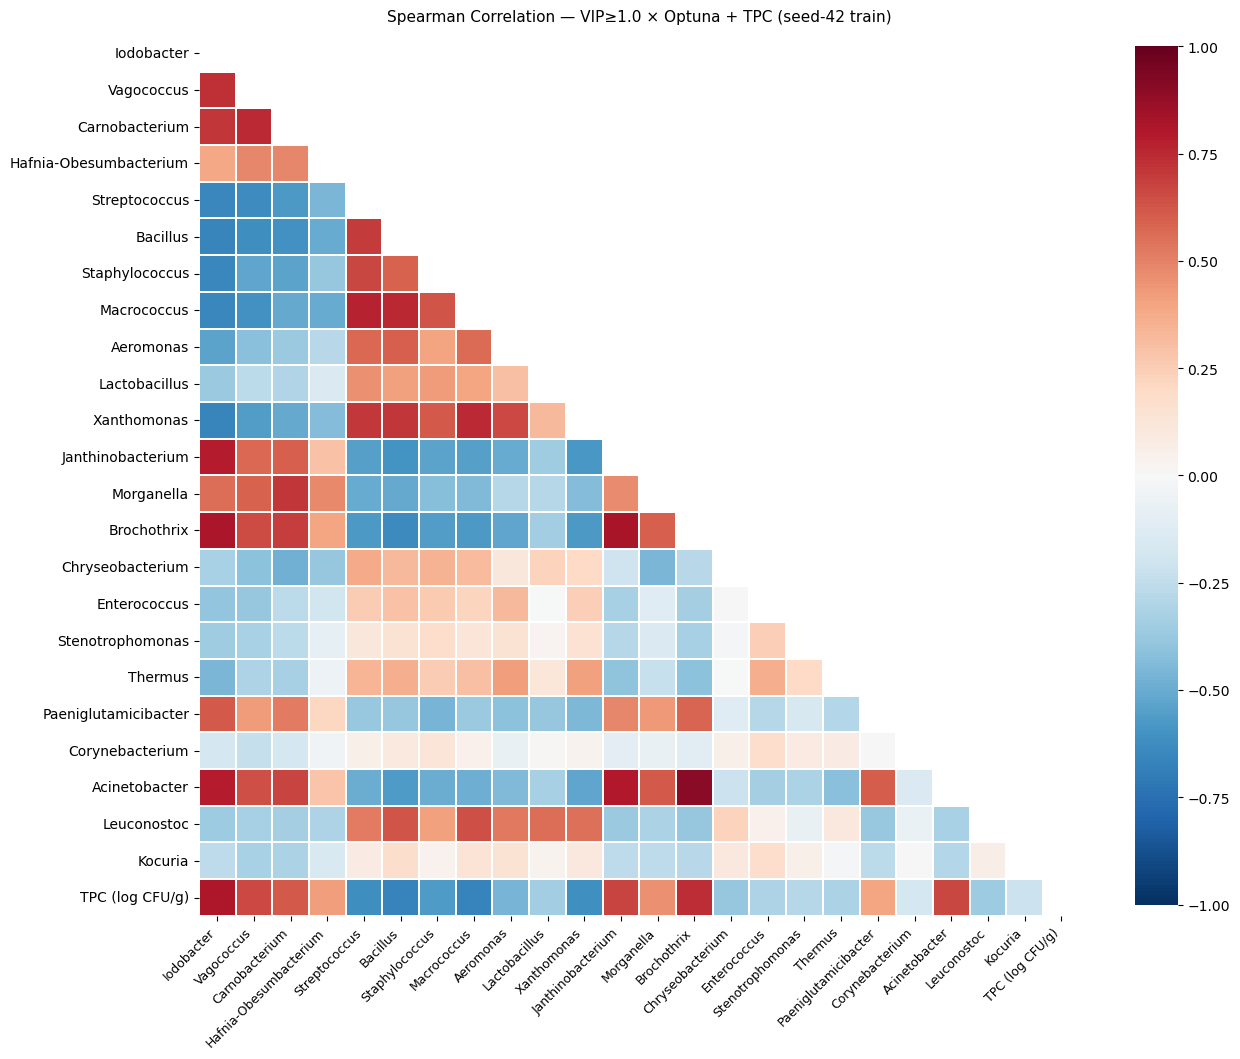

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_screen_vip_optuna_corr.png


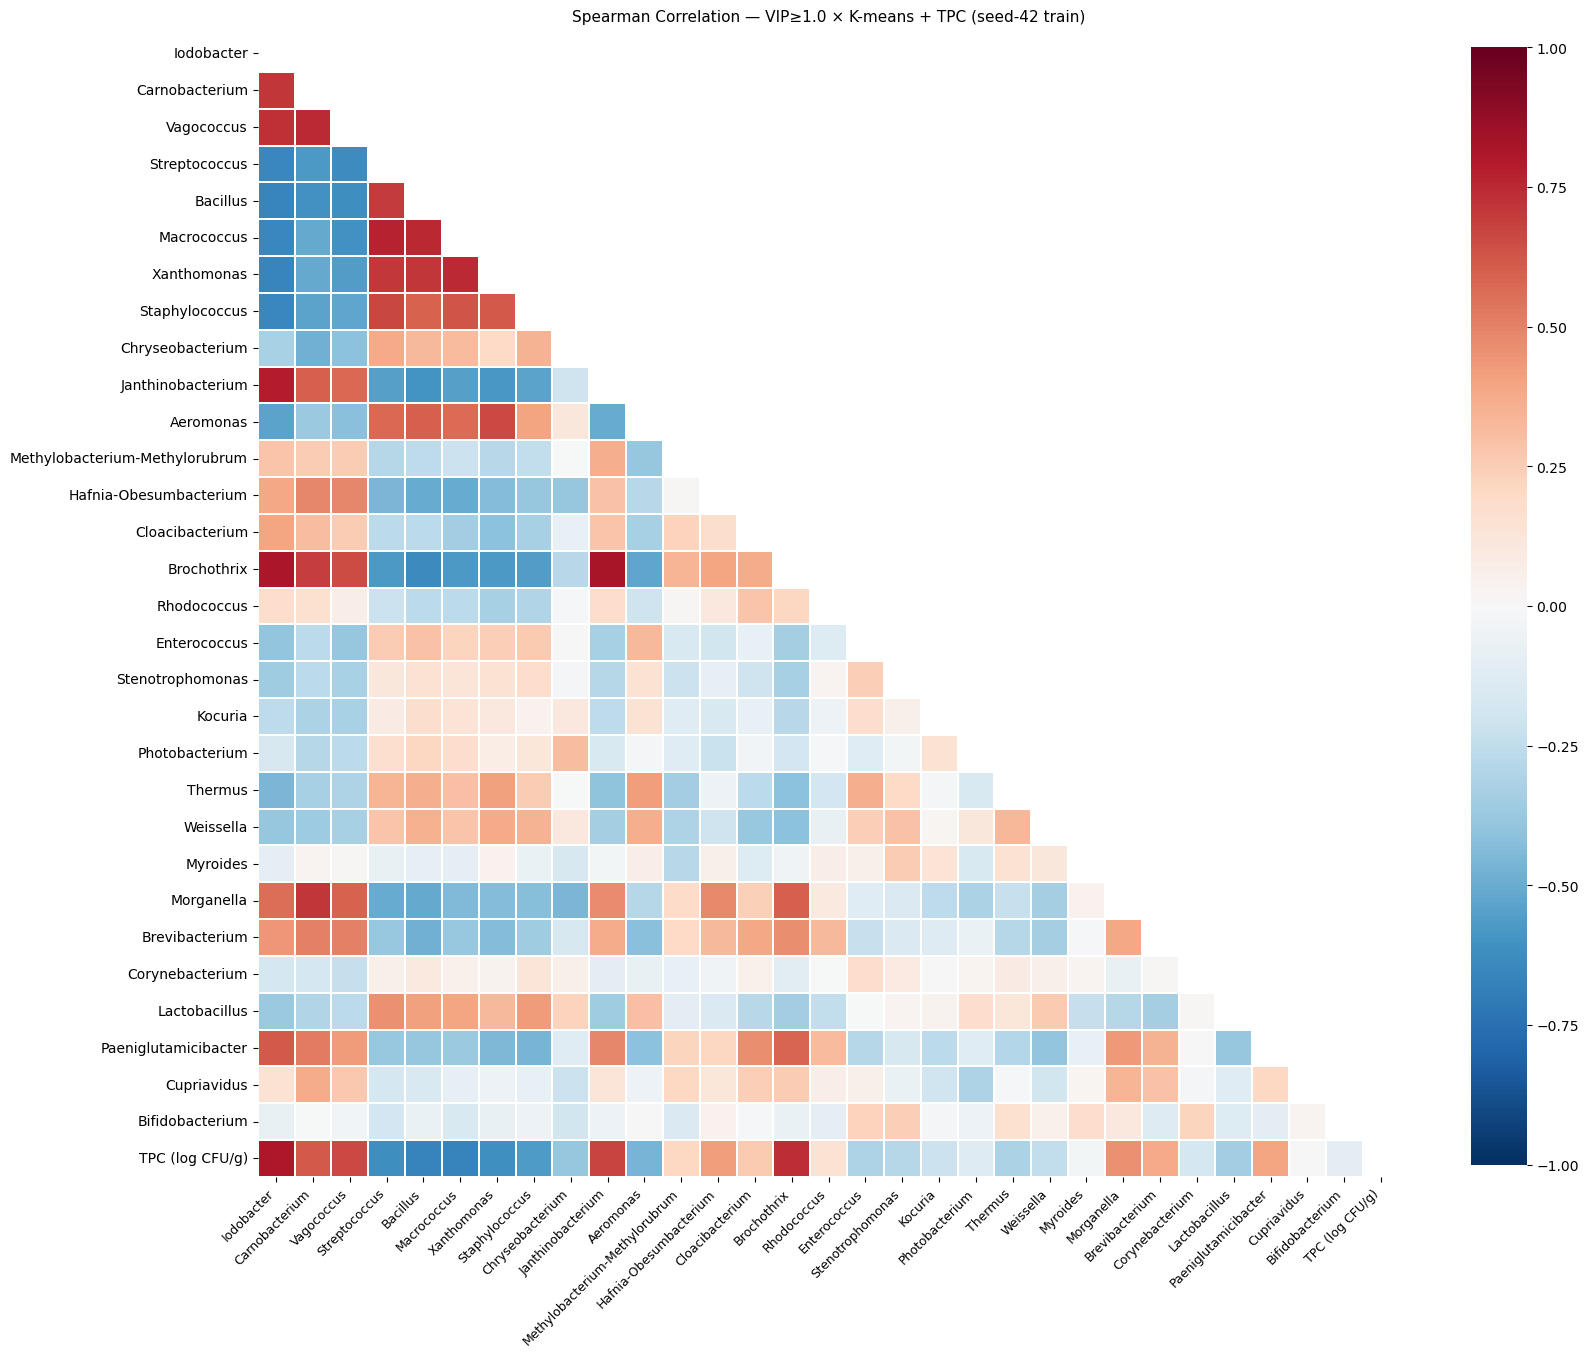

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_screen_vip_kmeans_corr.png


In [11]:
corr_heatmap(opt42, c1_feats,
             f'Spearman Correlation — FC Top10 + TPC (seed-{LABEL_SEED} train)',
             f"{SAVE_DIR}/fig_screen_fc10_corr.png")

corr_heatmap(opt42, c2_feats,
             f'Spearman Correlation — VIP≥1.0 × Optuna + TPC (seed-{LABEL_SEED} train)',
             f"{SAVE_DIR}/fig_screen_vip_optuna_corr.png")

corr_heatmap(km42, c4_feats,
             f'Spearman Correlation — VIP≥1.0 × K-means + TPC (seed-{LABEL_SEED} train)',
             f"{SAVE_DIR}/fig_screen_vip_kmeans_corr.png")

## 11. Save

In [12]:
screening_results = {
    'seeds':        SEEDS,
    'label_seed':   LABEL_SEED,
    'feature_cols': feature_cols,
    'cond1_optuna_fc10': {
        'per_seed_features': per_seed['cond1'],
        'per_seed_fc_df':    store['cond1']['fc_df'],
        'description': 'Optuna labeling + Fold-change Top10 (Day-based, train only, per seed)',
    },
    'cond2_optuna_vip': {
        'per_seed_features': per_seed['cond2'],
        'per_seed_vip_df':   store['cond2']['vip_df'],
        'per_seed_anova':    store['cond2']['anova'],
        'description': 'Optuna labeling + Day-ANOVA(q<0.05) → VIP≥1.0 (train only, per seed)',
    },
    'cond3_kmeans_fc10': {
        'per_seed_features': per_seed['cond3'],
        'per_seed_fc_df':    store['cond3']['fc_df'],
        'description': 'K-means labeling + Fold-change Top10 (Day-based, train only, per seed)',
    },
    'cond4_kmeans_vip': {
        'per_seed_features': per_seed['cond4'],
        'per_seed_vip_df':   store['cond4']['vip_df'],
        'per_seed_anova':    store['cond4']['anova'],
        'description': 'K-means labeling + Day-ANOVA(q<0.05) → VIP≥1.0 (train only, per seed)',
    },
}

with open(f"{PKL_DIR}/screening_results.pkl", 'wb') as f:
    pickle.dump(screening_results, f)

print(f"Saved: {PKL_DIR}/screening_results.pkl")

COND_LABEL = {
    'cond1': 'Optuna × FC Top10',
    'cond2': 'Optuna × VIP≥1.0',
    'cond3': 'K-means × FC Top10',
    'cond4': 'K-means × VIP≥1.0',
}
for cond, label in COND_LABEL.items():
    ns = [len(v) for v in per_seed[cond].values()]
    print(f"  [{label}]: {min(ns)}–{max(ns)} features/seed (mean={np.mean(ns):.1f})")

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/pkl/screening_results.pkl
  [Optuna × FC Top10]: 10–10 features/seed (mean=10.0)
  [Optuna × VIP≥1.0]: 22–28 features/seed (mean=24.8)
  [K-means × FC Top10]: 10–10 features/seed (mean=10.0)
  [K-means × VIP≥1.0]: 27–31 features/seed (mean=28.5)


## 12. For Paper figure

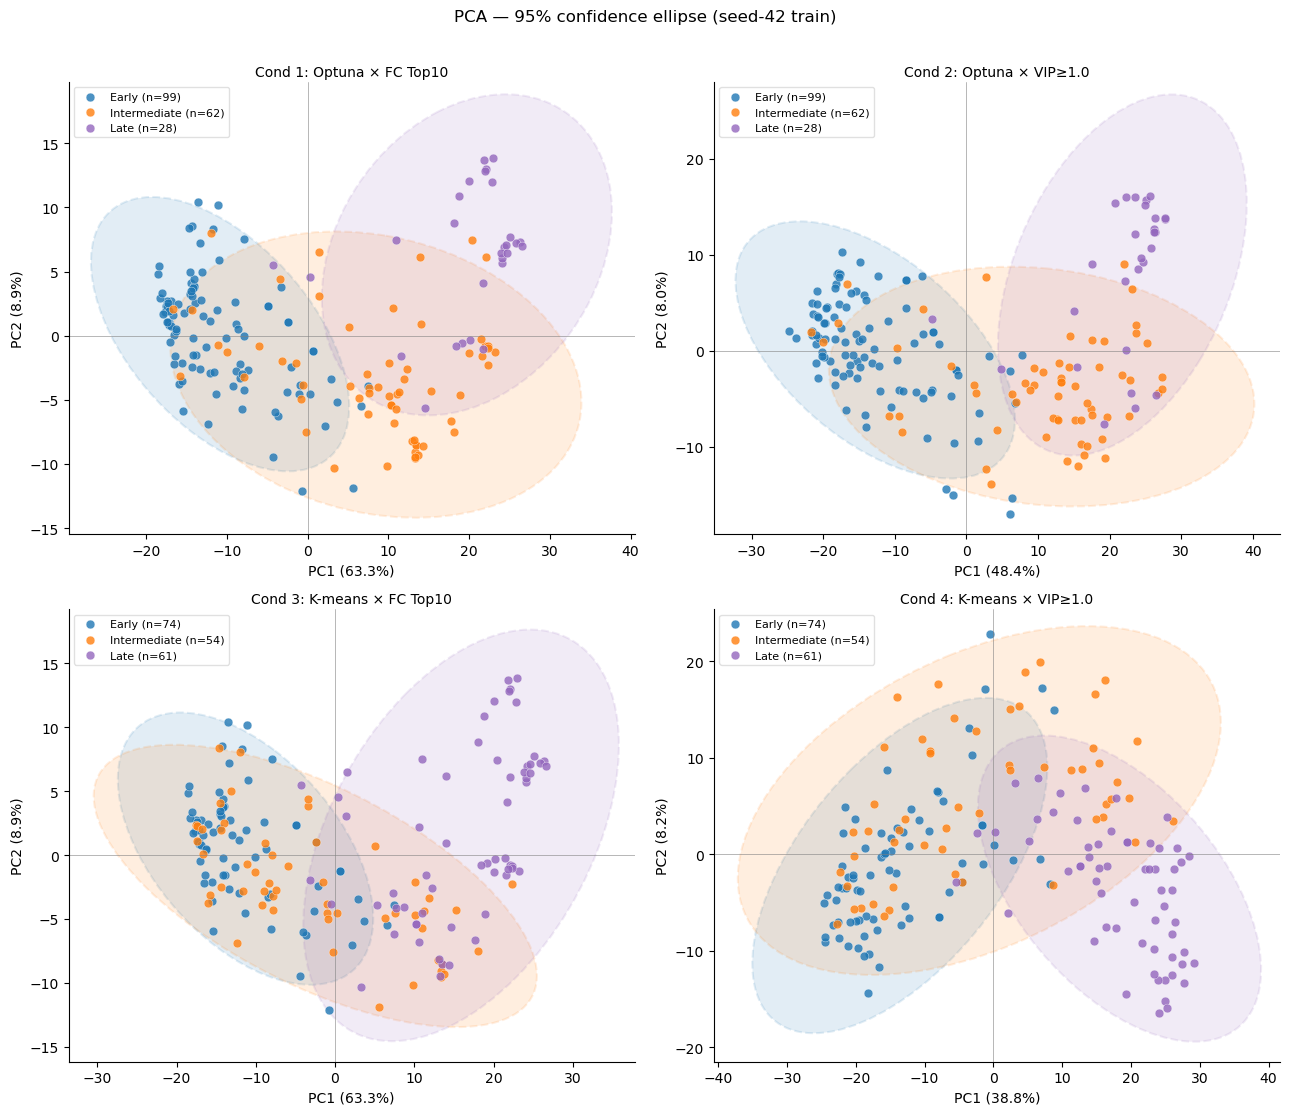

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_pca_4panel_ellipse.png


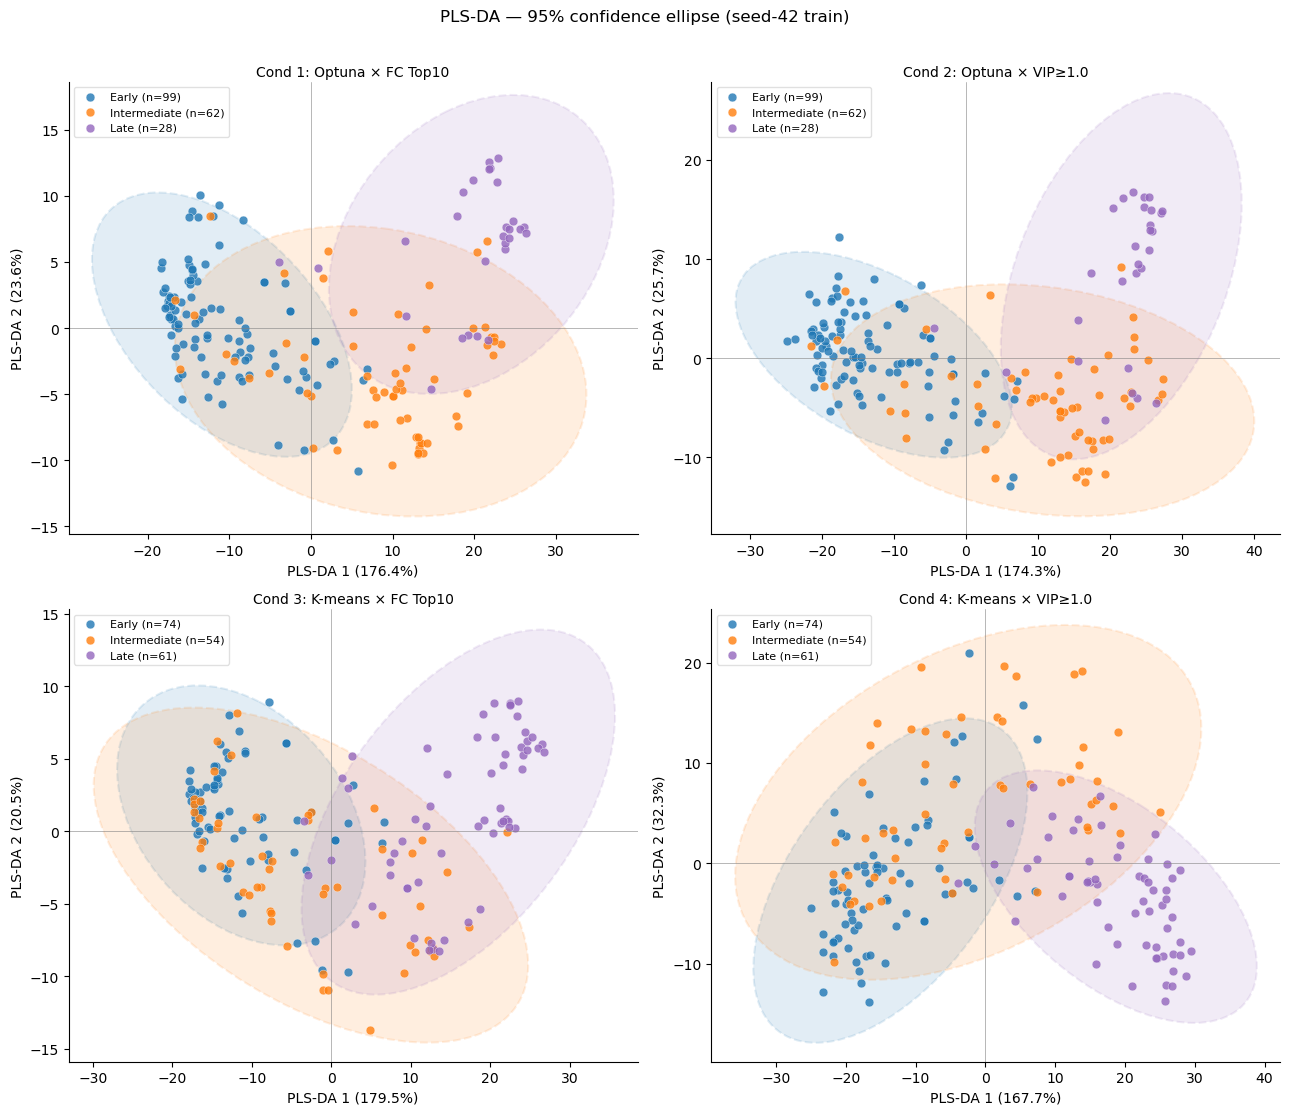

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_plsda_4panel_ellipse.png
── PCA Loading: Cond 1 ──


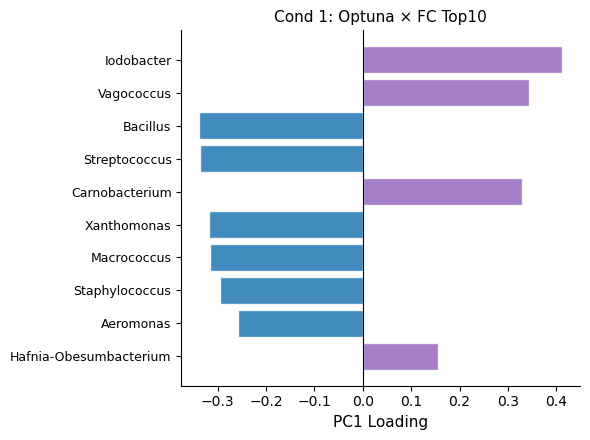

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_pcaload_optuna_fc10.png
── PCA Loading: Cond 2 ──


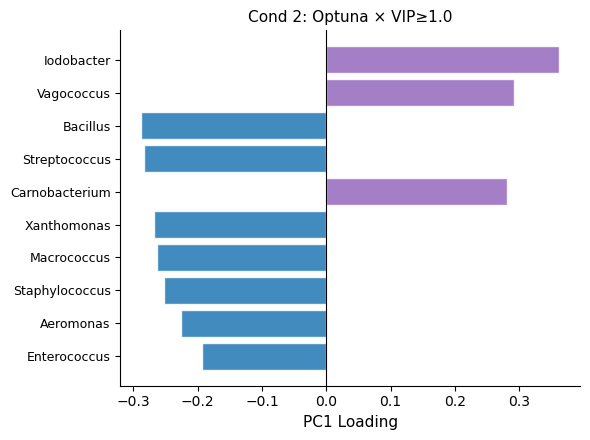

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_pcaload_optuna_vip.png
── PCA Loading: Cond 3 ──


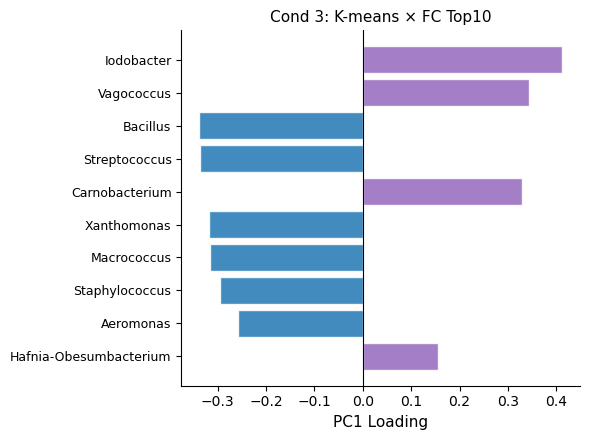

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_pcaload_kmeans_fc10.png
── PCA Loading: Cond 4 ──


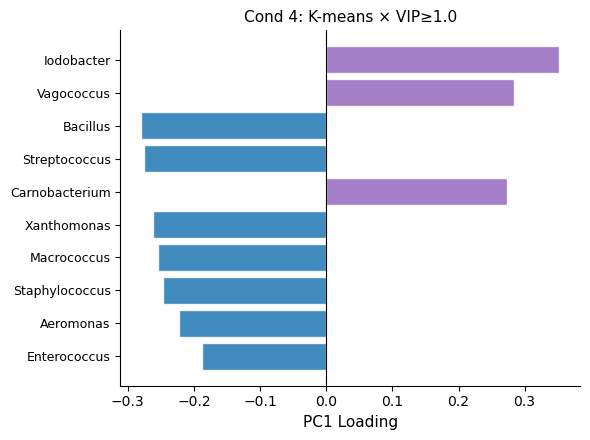

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_pcaload_kmeans_vip.png
── PLS-DA Loading: Cond 1 ──


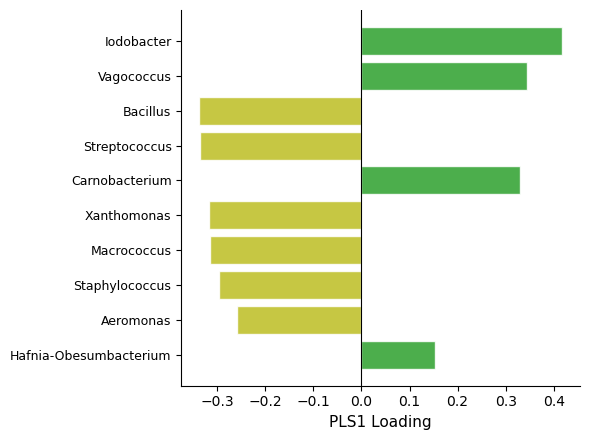

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_plsload_optuna_fc10.png
── PLS-DA Loading: Cond 2 ──


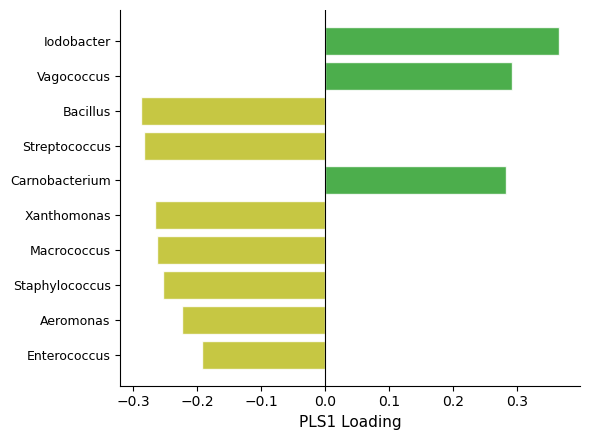

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_plsload_optuna_vip.png
── PLS-DA Loading: Cond 3 ──


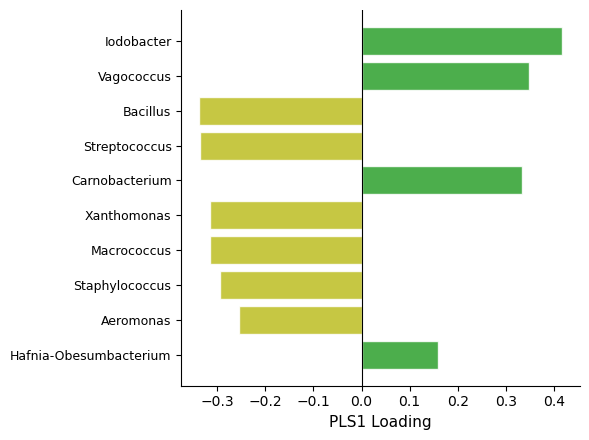

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_plsload_kmeans_fc10.png
── PLS-DA Loading: Cond 4 ──


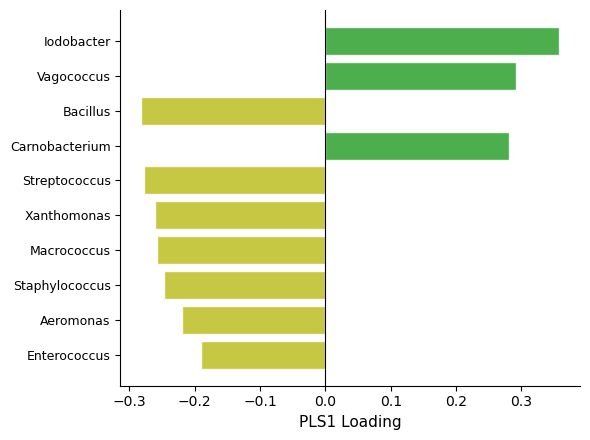

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/figures_screening/fig_plsload_kmeans_vip.png


In [13]:
panel_data = [
    {'X': X42_opt, 'y': y42_opt, 'feats': c1_feats, 'label': 'Cond 1: Optuna × FC Top10'},
    {'X': X42_opt, 'y': y42_opt, 'feats': c2_feats, 'label': 'Cond 2: Optuna × VIP≥1.0'},
    {'X': X42_km,  'y': y42_km,  'feats': c3_feats, 'label': 'Cond 3: K-means × FC Top10'},
    {'X': X42_km,  'y': y42_km,  'feats': c4_feats, 'label': 'Cond 4: K-means × VIP≥1.0'},
]

# ── 4-panel 합본 ─────────────────────────────────────────────────
pca_4panel(panel_data,   f"{SAVE_DIR}/fig_pca_4panel_ellipse.png")
plsda_4panel(panel_data, f"{SAVE_DIR}/fig_plsda_4panel_ellipse.png")

# ── PC1 Loading Bar (Cond 1, 2, 3, 4) ───────────────────────────
print("── PCA Loading: Cond 1 ──")
pc1_loading_bar(X42_opt, c1_feats, 'Cond 1: Optuna × FC Top10',
                f"{SAVE_DIR}/fig_pcaload_optuna_fc10.png")

print("── PCA Loading: Cond 2 ──")
pc1_loading_bar(X42_opt, c2_feats, 'Cond 2: Optuna × VIP≥1.0',
                f"{SAVE_DIR}/fig_pcaload_optuna_vip.png")

print("── PCA Loading: Cond 3 ──")
pc1_loading_bar(X42_km, c3_feats, 'Cond 3: K-means × FC Top10',
                f"{SAVE_DIR}/fig_pcaload_kmeans_fc10.png")

print("── PCA Loading: Cond 4 ──")
pc1_loading_bar(X42_km, c4_feats, 'Cond 4: K-means × VIP≥1.0',
                f"{SAVE_DIR}/fig_pcaload_kmeans_vip.png")

# ── PLS1 Loading Bar (Cond 1, 2, 3, 4) ──────────────────────────
print("── PLS-DA Loading: Cond 1 ──")
pls1_loading_bar(X42_opt, y42_opt, c1_feats,
                 f"{SAVE_DIR}/fig_plsload_optuna_fc10.png")

print("── PLS-DA Loading: Cond 2 ──")
pls1_loading_bar(X42_opt, y42_opt, c2_feats,
                 f"{SAVE_DIR}/fig_plsload_optuna_vip.png")

print("── PLS-DA Loading: Cond 3 ──")
pls1_loading_bar(X42_km, y42_km, c3_feats,
                 f"{SAVE_DIR}/fig_plsload_kmeans_fc10.png")

print("── PLS-DA Loading: Cond 4 ──")
pls1_loading_bar(X42_km, y42_km, c4_feats,
                 f"{SAVE_DIR}/fig_plsload_kmeans_vip.png")

In [15]:
# ── Table S: Seed별 Feature 선택 결과 Excel 출력 ──────────────────
import pandas as pd

OUT_DIR = f"{CODE_DIR}/data"

def _clean(name):
    return name.replace('g__', '')

# File 1: FC Top10 (Cond 1, label-independent)
with pd.ExcelWriter(f"{OUT_DIR}/tableS_fc_features.xlsx", engine='openpyxl') as writer:
    for seed in SEEDS:
        df = store['cond1']['fc_df'][seed].copy()
        df['feature'] = df['feature'].apply(_clean)
        df.columns = ['Genus', 'AbsChange (CLR max-min)', 'Direction (Late positive)']
        df.to_excel(writer, sheet_name=str(seed), index=False)
print("Saved: tableS_fc_features.xlsx")

# File 2: VIP (Optuna)
with pd.ExcelWriter(f"{OUT_DIR}/tableS_vip_optuna_features.xlsx", engine='openpyxl') as writer:
    for seed in SEEDS:
        df = store['cond2']['vip_df'][seed].copy()
        df['feature'] = df['feature'].apply(_clean)
        df['selected'] = df['vip_score'] >= 1.0
        df.columns = ['Genus', 'VIP Score', 'Selected (VIP>=1.0)']
        df.to_excel(writer, sheet_name=str(seed), index=False)
print("Saved: tableS_vip_optuna_features.xlsx")

# File 3: VIP (K-means)
with pd.ExcelWriter(f"{OUT_DIR}/tableS_vip_kmeans_features.xlsx", engine='openpyxl') as writer:
    for seed in SEEDS:
        df = store['cond4']['vip_df'][seed].copy()
        df['feature'] = df['feature'].apply(_clean)
        df['selected'] = df['vip_score'] >= 1.0
        df.columns = ['Genus', 'VIP Score', 'Selected (VIP>=1.0)']
        df.to_excel(writer, sheet_name=str(seed), index=False)
print("Saved: tableS_vip_kmeans_features.xlsx")

Saved: tableS_fc_features.xlsx
Saved: tableS_vip_optuna_features.xlsx
Saved: tableS_vip_kmeans_features.xlsx
